In [ ]:
import os
import glob
import h5py
import scipy.io as io
import scipy.ndimage
import scipy.spatial
import numpy as np
import cv2
from tqdm import tqdm 


def generate_ucf_adaptive_density_map(img_shape, pts):
    """Generates density map using highly-optimized localized k-NN adaptive math."""
    density_map = np.zeros(img_shape, dtype=np.float32)
    num_points = len(pts)
    
    if num_points == 0:
        return density_map

    # Fast nearest neighbors
    tree = scipy.spatial.KDTree(pts.copy())
    distances, _ = tree.query(pts, k=4)
    
    for i, pt in enumerate(pts):
        pt_x, pt_y = int(pt[0]), int(pt[1])
        
        if pt_y >= img_shape[0] or pt_x >= img_shape[1] or pt_y < 0 or pt_x < 0:
            continue
        
        # 1. Adaptive sigma calculation
        # Fallback to sigma=5 if too few points
        avg_distance = np.mean(distances[i][1:4]) if num_points > 3 else 15.0 
        adaptive_sigma = 0.3 * avg_distance
        adaptive_sigma = np.clip(adaptive_sigma, a_min=1.0, a_max=20.0)
        
        # --- THE SPEED UP: Localized Bounding Box ---
        # 3*sigma safely captures ~99.7% of the Gaussian distribution's spread
        k_size = int(3 * adaptive_sigma) 
        
        # 2. Calculate bounds, ensuring we don't go outside the image borders
        y1 = max(0, pt_y - k_size)
        y2 = min(img_shape[0], pt_y + k_size + 1)
        x1 = max(0, pt_x - k_size)
        x2 = min(img_shape[1], pt_x + k_size + 1)
        
        # 3. Find the local coordinate of the point inside our tiny box
        loc_y = pt_y - y1
        loc_x = pt_x - x1
        
        # 4. Create a tiny localized map, put the point, and blur it
        loc_pt_map = np.zeros((y2 - y1, x2 - x1), dtype=np.float32)
        loc_pt_map[loc_y, loc_x] = 1.0
        
        loc_density = scipy.ndimage.gaussian_filter(loc_pt_map, sigma=adaptive_sigma)
        
        # 5. Add the blurred small patch back into the giant density map
        density_map[y1:y2, x1:x2] += loc_density
        
    return density_map


def process_ucf_qnrf(img_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    
    # CHANGE 1: Removed the [:10] slice at the end of this line
    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg'))) 
    # img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))[:5]
    
    print(f"🚀 Starting processing for {len(img_paths)} images...\n")
    
    for img_path in tqdm(img_paths, desc="Generating Heatmaps"):
        img_name = os.path.basename(img_path)
        name, _ = os.path.splitext(img_name)
        
        mat_path = os.path.join(img_dir, f"{name}_ann.mat")
        h5_path = os.path.join(output_dir, f"{name}.h5")
        
        if os.path.exists(h5_path):
            continue 
            
        if not os.path.exists(mat_path):
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        
        # --- THE SAFETY NET ---
        try:
            mat = io.loadmat(mat_path)
            if 'annPoints' in mat:
                pts = mat['annPoints']
            else:
                print(f"⚠️ Skipping {img_name}: No 'annPoints' key found.")
                continue
        except Exception as e:
            print(f"❌ Corrupt .mat file for {img_name}: {e}")
            continue
            
        density_map = generate_ucf_adaptive_density_map((h, w), pts)
        
        with h5py.File(h5_path, 'w') as hf:
            hf.create_dataset('density', data=density_map, compression="gzip")

if __name__ == "__main__":
    # CHANGE 2: Update these paths to point to where the data is on your Workstation!
    # Example: "D:/Datasets/UCF-QNRF_ECCV18/Train"
    WORKSTATION_TRAIN_IMG_DIR = "/kaggle/input/datasets/faihajalamtopu/ucf-qnrf/UCF-QNRF_ECCV18/Train" 
    WORKSTATION_OUTPUT_DIR = "/kaggle/working/ucf_train_h5"
    
    process_ucf_qnrf(WORKSTATION_TRAIN_IMG_DIR, WORKSTATION_OUTPUT_DIR)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import mobilenet_v3_large

class MobileNetV3MultiScale(nn.Module):
    def __init__(self):
        super(MobileNetV3MultiScale, self).__init__()
        self.mobilenet_features = mobilenet_v3_large(pretrained=True).features
        self.feature_extraction_points = [6, 12, 16]

    def forward(self, x):
        features = []
        for i, module in enumerate(self.mobilenet_features):
            x = module(x)
            if i in self.feature_extraction_points:
                features.append(x)
        return features

class AdaptiveFusionModule(nn.Module):
    def __init__(self, in_channels_list=[40, 112, 960], out_channels=128): # 960 fix applied!
        super(AdaptiveFusionModule, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=1) 
            for in_channels in in_channels_list
        ])
        self.weight_predictor = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),
            nn.Linear(in_channels_list[-1], len(in_channels_list)), 
            nn.Softmax(dim=1) 
        )

    def forward(self, features):
        weights = self.weight_predictor(features[-1])
        fused_features = []
        target_size = features[0].shape[2:] 

        for i, feat in enumerate(features):
            processed_feat = self.convs[i](feat)
            if processed_feat.shape[2:] != target_size:
                processed_feat = F.interpolate(processed_feat, size=target_size, mode='bilinear', align_corners=False)
            weight_i = weights[:, i].view(-1, 1, 1, 1)
            weighted_feat = processed_feat * weight_i
            fused_features.append(weighted_feat)
        return sum(fused_features)

class MyMAN(nn.Module):
    def __init__(self, in_channels):
        super(MyMAN, self).__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels // 8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, kernel_size=1),
            nn.Sigmoid()
        )
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(in_channels, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        ca_map = self.channel_attention(x)
        x = x * ca_map
        sa_map = self.spatial_attention(x)
        x = x * sa_map
        return x

class EdgeCrowdCounter(nn.Module):
    def __init__(self, num_output_channels=1):
        super(EdgeCrowdCounter, self).__init__()
        self.backbone = MobileNetV3MultiScale()
        in_channels_list = [40, 112, 960] 
        fused_channels = 128 
        self.adaptive_fusion = AdaptiveFusionModule(in_channels_list, fused_channels)
        self.man = MyMAN(fused_channels)
        self.density_map_head = nn.Sequential(
            nn.Conv2d(fused_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_output_channels, kernel_size=1),
            nn.ReLU(inplace=True) 
        )

    def forward(self, x):
        features = self.backbone(x)
        fused_output = self.adaptive_fusion(features)
        man_output = self.man(fused_output)
        density_map = self.density_map_head(man_output)
        return density_map

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from math import exp

def gaussian(window_size, sigma):
    gauss = torch.Tensor([exp(-(x - window_size//2)**2/float(2*sigma**2)) for x in range(window_size)])
    return gauss/gauss.sum()

def create_window(window_size, channel):
    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
    window = torch.autograd.Variable(_2D_window.expand(channel, 1, window_size, window_size).contiguous())
    return window

def _ssim(img1, img2, window, window_size, channel, size_average=True):
    mu1 = F.conv2d(img1, window, padding=window_size//2, groups=channel)
    mu2 = F.conv2d(img2, window, padding=window_size//2, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size//2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size//2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=window_size//2, groups=channel) - mu1_mu2

    C1 = 0.01**2
    C2 = 0.03**2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    if size_average:
        return ssim_map.mean()
    else:
        return ssim_map.mean(1).mean(1).mean(1)

class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, size_average=True):
        super(SSIMLoss, self).__init__()
        self.window_size = window_size
        self.size_average = size_average
        self.channel = 1
        self.window = create_window(window_size, self.channel)

    def forward(self, img1, img2):
        (_, channel, _, _) = img1.size()
        if channel == self.channel and self.window.data.type() == img1.data.type():
            window = self.window
        else:
            window = create_window(self.window_size, channel)
            if img1.is_cuda:
                window = window.cuda(img1.get_device())
            window = window.type_as(img1)
            self.window = window
            self.channel = channel
        
        # We return 1 - SSIM because we want to MINIMIZE the loss (SSIM is 1 when identical)
        return 1.0 - _ssim(img1, img2, window, self.window_size, channel, self.size_average)

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.001):
        super(CombinedLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.ssim = SSIMLoss()
        self.alpha = alpha

    def forward(self, pred, target):
        loss_mse = self.mse(pred, target)
        loss_ssim = self.ssim(pred, target)
        return loss_mse + (self.alpha * loss_ssim)

In [3]:
import os
import glob
import cv2
import h5py
import torch
import numpy as np
import random
from torch.utils.data import Dataset
from torchvision import transforms

class CrowdDataset(Dataset):
    def __init__(self, img_dir, h5_dir, crop_size=512, downsample_ratio=8, scale_range=(0.7, 1.3)):
        self.crop_size = crop_size
        self.downsample_ratio = downsample_ratio
        self.scale_range = scale_range # Added scaling bounds
        
        # Safely grab ONLY images that have a matching .h5 file
        all_imgs = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        self.img_paths = [
            img for img in all_imgs 
            if os.path.exists(os.path.join(h5_dir, os.path.basename(img).replace('.jpg', '.h5')))
        ]
        
        self.h5_dir = h5_dir
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        h5_path = os.path.join(self.h5_dir, os.path.basename(img_path).replace('.jpg', '.h5'))
        with h5py.File(h5_path, 'r') as hf:
            density_map = np.array(hf['density'])

        # ==========================================
        # 🚀 THE UPGRADE: SCALE JITTERING
        # ==========================================
        # 1. Select a dynamic scale factor
        scale = random.uniform(self.scale_range[0], self.scale_range[1])
        
        h, w = img.shape[:2]
        new_h, new_w = int(h * scale), int(w * scale)
        
        # 2. Lock in the true headcount before altering the array
        original_total_count = np.sum(density_map)
        
        # 3. Resize both
        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        density_map = cv2.resize(density_map, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        
        # 4. Conservation of Mass: Restore the lost/gained headcount
        new_total_count = np.sum(density_map)
        if new_total_count > 0:
            density_map = density_map * (original_total_count / new_total_count)
            
        # Update dimensions for the cropping logic below
        h, w = img.shape[:2]
        # ==========================================

        if h < self.crop_size or w < self.crop_size:
            pad_h = max(0, self.crop_size - h)
            pad_w = max(0, self.crop_size - w)
            img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), mode='constant')
            density_map = np.pad(density_map, ((0, pad_h), (0, pad_w)), mode='constant')
            h, w = img.shape[:2]

        x1 = random.randint(0, w - self.crop_size)
        y1 = random.randint(0, h - self.crop_size)
        img_crop = img[y1:y1+self.crop_size, x1:x1+self.crop_size]
        density_crop = density_map[y1:y1+self.crop_size, x1:x1+self.crop_size]

        target_h = self.crop_size // self.downsample_ratio
        target_w = self.crop_size // self.downsample_ratio
        original_crop_count = np.sum(density_crop) 
        
        density_crop_resized = cv2.resize(density_crop, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
        resized_crop_count = np.sum(density_crop_resized)
        if resized_crop_count > 0:
            density_crop_resized = density_crop_resized * (original_crop_count / resized_crop_count)

        img_tensor = self.transform(img_crop)
        density_tensor = torch.from_numpy(density_crop_resized).unsqueeze(0).float()

        return img_tensor, density_tensor

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
# Assuming your CrowdDataset class is defined in a cell above this one!

# ==========================================
# 🛠️ AUDITED KAGGLE PATHS
# ==========================================
# Double-check this input path matches your UCF-QNRF dataset mount exactly
KAGGLE_TRAIN_IMG_DIR = "/kaggle/input/datasets/faihajalamtopu/ucf-qnrf/UCF-QNRF_ECCV18/Train" 

# This must point to where your earlier script saved the training heatmaps
KAGGLE_TRAIN_H5_DIR  = "/kaggle/working/ucf_train_h5" 

def test_dataloader():
    print("🔄 Initializing Dataset pipeline...")
    dataset = CrowdDataset(img_dir=KAGGLE_TRAIN_IMG_DIR, h5_dir=KAGGLE_TRAIN_H5_DIR)
    
    if len(dataset) == 0:
        print("❌ FATAL: Dataset loaded 0 images. Verify your KAGGLE_TRAIN_H5_DIR path.")
        print("Make sure your training heatmaps have finished generating in the /working/ directory!")
        return
        
    print(f"✅ Dataset verified: {len(dataset)} valid image-heatmap pairs found.")
    
    loader = DataLoader(dataset, batch_size=2, shuffle=True)
    images, heatmaps = next(iter(loader))
    
    # Un-normalize image for viewing
    img = images[0].numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    heatmap = heatmaps[0].squeeze().numpy()
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Random 512x512 Crop (Scale Jittered)")
    
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title(f"Target 64x64 Heatmap (Count: {np.sum(heatmap):.2f})")
    
    plt.show()

if __name__ == "__main__":
    test_dataloader()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# ==========================================
# 🛠️ KAGGLE PATHS & CONFIG
# ==========================================
KAGGLE_TRAIN_IMG_DIR = "/kaggle/input/datasets/faihajalamtopu/ucf-qnrf/UCF-QNRF_ECCV18/Train" 
KAGGLE_TRAIN_H5_DIR  = "/kaggle/working/ucf_train_h5"

CHECKPOINT_FILE = "/kaggle/working/latest_checkpoint.pth" 
BEST_MODEL_FILE = "/kaggle/working/best_edge_crowd_model.pth"

def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ Training on: {device}")
    
    dataset = CrowdDataset(img_dir=KAGGLE_TRAIN_IMG_DIR, h5_dir=KAGGLE_TRAIN_H5_DIR, crop_size=512)
    
    if len(dataset) == 0:
        print("❌ FATAL: No training data found. Check your heatmap folder!")
        return
        
    # Batch size 2 is safer for Kaggle's T4 GPU to avoid Out-Of-Memory errors
    loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)
    
    model = EdgeCrowdCounter().to(device)
    
    # 🚀 THE UPGRADE: Using the new Combined Loss
    criterion = CombinedLoss(alpha=0.0001) 
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    # ⚠️ SET TO 2 FOR THE SMOKE TEST
    epochs = 120 
    start_epoch = 0
    best_loss = float('inf')
    
    # Resume Logic (Crucial for Kaggle preemptions)
    if os.path.exists(CHECKPOINT_FILE):
        print("🔄 Resuming from checkpoint...")
        checkpoint = torch.load(CHECKPOINT_FILE)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']
        
    for epoch in range(start_epoch, epochs):
        model.train()
        epoch_loss = 0.0
        
        loop = tqdm(loader, leave=True, desc=f"Epoch [{epoch+1}/{epochs}]")
        
        for batch_idx, (images, heatmaps) in enumerate(loop):
            images, heatmaps = images.to(device), heatmaps.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, heatmaps)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())
            
        avg_loss = epoch_loss / len(loader)
        print(f"📈 Epoch [{epoch+1}/{epochs}] Summary | Avg Combined Loss: {avg_loss:.6f}")
        
        checkpoint = {
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_loss': best_loss
        }
        torch.save(checkpoint, CHECKPOINT_FILE)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), BEST_MODEL_FILE)
            print(f"💾 New Best Model Saved! (Loss: {best_loss:.6f})\n")

if __name__ == "__main__":
    train()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 81.7MB/s]


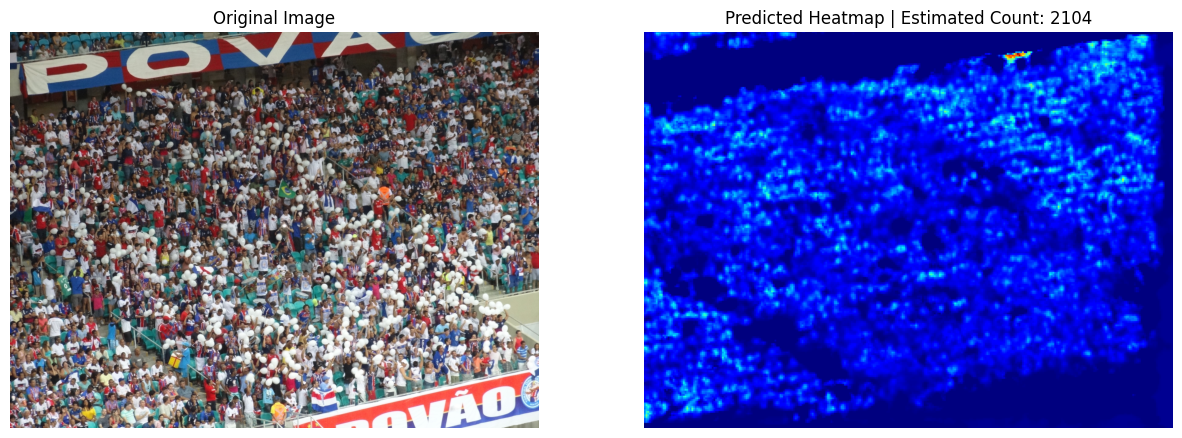

In [4]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

def predict_and_show(model_path, img_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load Model
    model = EdgeCrowdCounter().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 2. Pre-process Image
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_raw = Image.open(img_path).convert('RGB')
    img_tensor = transform(img_raw).unsqueeze(0).to(device)
    
    # 3. Dynamic Padding (Must be divisible by 32 for MobileNetV3)
    _, _, h, w = img_tensor.shape
    pad_h = (32 - (h % 32)) % 32
    pad_w = (32 - (w % 32)) % 32
    img_tensor = F.pad(img_tensor, (0, pad_w, 0, pad_h))
    
    # 4. Inference
    with torch.no_grad():
        pred_map = model(img_tensor)
        # Remove padding from the output map to match original image size
        pred_map = pred_map[:, :, :h//8, :w//8] # Model downsamples by 8
        count = torch.sum(pred_map).item()
    
    # 5. Visualization
    pred_map_np = pred_map.squeeze().cpu().numpy()
    
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(img_raw)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(pred_map_np, cmap='jet')
    plt.title(f"Predicted Heatmap | Estimated Count: {round(count)}")
    plt.axis('off')
    
    plt.show()

# --- RUN THE TEST ---
# Path to your freshly trained weights (Assuming you uploaded them as a dataset!)
BEST_MODEL = "/kaggle/input/datasets/maaujo/new-model-weights/best_edge_crowd_model (1).pth"

# Double check this path in your sidebar!
TEST_IMAGE = "/kaggle/input/datasets/faihajalamtopu/ucf-qnrf/UCF-QNRF_ECCV18/Test/img_0001.jpg"

predict_and_show(BEST_MODEL, TEST_IMAGE)

In [5]:
import os
import glob
import cv2
import h5py
import scipy.io as io
import scipy.ndimage
import numpy as np
from tqdm import tqdm

def generate_and_evaluate_ucf():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ Running UCF-QNRF Eval on: {device}")

    # --- PATHS (Double check the 'datasets' part) ---
    IMG_DIR = "/kaggle/input/datasets/faihajalamtopu/ucf-qnrf/UCF-QNRF_ECCV18/Test"
    GT_DIR  = "/kaggle/input/datasets/faihajalamtopu/ucf-qnrf/UCF-QNRF_ECCV18/Test"
    H5_DIR  = "/kaggle/working/ucf_test_h5"
    MODEL_PATH = "/kaggle/input/datasets/maaujo/new-model-weights/best_edge_crowd_model (1).pth"

    # 1. GENERATE HEATMAPS
    os.makedirs(H5_DIR, exist_ok=True)
    img_paths = sorted(glob.glob(os.path.join(IMG_DIR, '*.jpg')))
    
    print("📦 Generating UCF Ground Truth Heatmaps...")
    for img_path in tqdm(img_paths, desc="Heatmaps"):
        name = os.path.basename(img_path).replace('.jpg', '')
        mat_path = os.path.join(GT_DIR, f"{name}_ann.mat") 
        h5_path = os.path.join(H5_DIR, f"{name}.h5")

        if os.path.exists(h5_path) or not os.path.exists(mat_path): continue

        img = cv2.imread(img_path)
        pts = io.loadmat(mat_path)['annPoints']
        density = np.zeros(img.shape[:2], dtype=np.float32)
        
        if len(pts) > 0:
            for pt in pts:
                pt_y, pt_x = int(pt[1]), int(pt[0])
                if pt_y < img.shape[0] and pt_x < img.shape[1]: density[pt_y, pt_x] = 1
            density = scipy.ndimage.gaussian_filter(density, sigma=4)

        with h5py.File(h5_path, 'w') as hf: hf.create_dataset('density', data=density)

    # 2. EVALUATE MODEL
    model = EdgeCrowdCounter().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    total_mae, total_mse, count_processed = 0.0, 0.0, 0
    print("\n🚀 Evaluating Model...")

    with torch.no_grad():
        for img_path in tqdm(img_paths, desc="Evaluation"):
            name = os.path.basename(img_path).replace('.jpg', '')
            h5_path = os.path.join(H5_DIR, f"{name}.h5")
            if not os.path.exists(h5_path): continue

            with h5py.File(h5_path, 'r') as hf: gt_count = np.sum(np.array(hf['density']))

            img_tensor = transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
            
            _, _, h, w = img_tensor.shape
            img_tensor = F.pad(img_tensor, (0, (32 - (w % 32)) % 32, 0, (32 - (h % 32)) % 32))

            pred_count = torch.sum(model(img_tensor)).item()
            error = abs(pred_count - gt_count)
            total_mae += error
            total_mse += error ** 2
            count_processed += 1

    print("\n" + "="*40)
    print("🏆 FINAL UCF-QNRF TEST RESULTS 🏆")
    print("="*40)
    print(f"Mean Absolute Error (MAE): {total_mae / count_processed:.2f}")
    print(f"Root Mean Squared Error (RMSE): {np.sqrt(total_mse / count_processed):.2f}")
    print("="*40)

generate_and_evaluate_ucf()

🖥️ Running UCF-QNRF Eval on: cuda
📦 Generating UCF Ground Truth Heatmaps...


Heatmaps: 100%|██████████| 334/334 [02:41<00:00,  2.07it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🚀 Evaluating Model...


Evaluation: 100%|██████████| 334/334 [02:08<00:00,  2.60it/s]


🏆 FINAL UCF-QNRF TEST RESULTS 🏆
Mean Absolute Error (MAE): 174.51
Root Mean Squared Error (RMSE): 303.64


In [7]:
# (Assuming imports from above are already loaded)

def evaluate_shanghai_cross_dataset():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    MODEL_PATH = "/kaggle/input/datasets/maaujo/new-model-weights/best_edge_crowd_model (1).pth"
    SH_ROOT = "/kaggle/input/datasets/hosammhmdali/shanghai-tech-dataset-part-a-and-part-b/ShanghaiTech"

    model = EdgeCrowdCounter().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    results = {}
    for part in ['A', 'B']:
        img_dir = f"{SH_ROOT}/part_{part}/test_data/images"
        gt_dir = f"{SH_ROOT}/part_{part}/test_data/ground-truth"
        h5_dir = f"/kaggle/working/sh_part_{part}_test_h5"
        os.makedirs(h5_dir, exist_ok=True)
        
        img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        total_mae, total_mse, count = 0, 0, 0
        
        for img_path in tqdm(img_paths, desc=f"Evaluating Part {part}"):
            clean_name = os.path.basename(img_path).replace("processed_", "").replace(".jpg", "")
            h5_path = os.path.join(h5_dir, f"{clean_name}.h5")
            
            # 1. On-the-fly Heatmap Gen if missing
            if not os.path.exists(h5_path):
                mat_path = os.path.join(gt_dir, f"GT_{clean_name}.mat")
                if not os.path.exists(mat_path): continue
                try:
                    pts = io.loadmat(mat_path)['image_info'][0, 0][0, 0][0]
                    img_shape = cv2.imread(img_path).shape[:2]
                    density = np.zeros(img_shape, dtype=np.float32)
                    for pt in pts:
                        pt_x, pt_y = int(pt[0]), int(pt[1])
                        if pt_y < img_shape[0] and pt_x < img_shape[1]: density[pt_y, pt_x] = 1
                    density = scipy.ndimage.gaussian_filter(density, sigma=4)
                    with h5py.File(h5_path, 'w') as hf: hf.create_dataset('density', data=density)
                except: continue

            # 2. Evaluation
            with h5py.File(h5_path, 'r') as hf: gt_count = np.sum(np.array(hf['density']))

            img_tensor = transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
            _, _, h, w = img_tensor.shape
            img_tensor = F.pad(img_tensor, (0, (32 - (w % 32)) % 32, 0, (32 - (h % 32)) % 32))

            with torch.no_grad(): pred_count = torch.sum(model(img_tensor)).item()

            error = abs(pred_count - gt_count)
            total_mae += error
            total_mse += error ** 2
            count += 1
            
        results[part] = (total_mae/count, np.sqrt(total_mse/count))

    print("\n" + "="*40)
    print(f"📊 SHANGHAITECH CROSS-DATASET RESULTS")
    print("="*40)
    print(f"Part A (Dense) - MAE: {results['A'][0]:.2f} | RMSE: {results['A'][1]:.2f}")
    print(f"Part B (CCTV)  - MAE: {results['B'][0]:.2f} | RMSE: {results['B'][1]:.2f}")
    print("="*40)

evaluate_shanghai_cross_dataset()

Evaluating Part B: 100%|██████████| 316/316 [01:39<00:00,  3.18it/s]


📊 SHANGHAITECH CROSS-DATASET RESULTS
Part A (Dense) - MAE: 128.58 | RMSE: 197.30
Part B (CCTV)  - MAE: 31.10 | RMSE: 42.83
